In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("Supplement_Sales_Weekly_Expanded.csv")

In [4]:
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


In [5]:
df["Date"]=pd.to_datetime(df["Date"])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            4384 non-null   datetime64[ns]
 1   Product Name    4384 non-null   object        
 2   Category        4384 non-null   object        
 3   Units Sold      4384 non-null   int64         
 4   Price           4384 non-null   float64       
 5   Revenue         4384 non-null   float64       
 6   Discount        4384 non-null   float64       
 7   Units Returned  4384 non-null   int64         
 8   Location        4384 non-null   object        
 9   Platform        4384 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 342.6+ KB


In [7]:
df.isnull().sum()

,0
Date,0
Product Name,0
Category,0
Units Sold,0
Price,0
Revenue,0
Discount,0
Units Returned,0
Location,0
Platform,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Date,Units Sold,Price,Revenue,Discount,Units Returned
count,4384,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000
mean,2022-08-18 12:00:00,150.200274,34.781229,5226.569446,0.124398,1.531478
min,2020-01-06 00:00:00,103.000000,10.000000,1284.000000,0.000000,0.000000
25%,2021-04-26 00:00:00,142.000000,22.597500,3349.372500,0.060000,1.000000
50%,2022-08-18 12:00:00,150.000000,34.720000,5173.140000,0.120000,1.000000
75%,2023-12-11 00:00:00,158.000000,46.712500,7009.960000,0.190000,2.000000
max,2025-03-31 00:00:00,194.000000,59.970000,10761.850000,0.250000,8.000000
std,NaN,12.396099,14.198309,2192.491946,0.071792,1.258479


In [10]:
df.describe(include="object")

,Product Name,Category,Location,Platform
count,4384,4384,4384,4384
unique,16,10,3,3
top,Whey Protein,Vitamin,Canada,iHerb
freq,274,822,1507,1499


In [11]:
daily_sales=df.groupby("Date").agg({
    "Revenue":"sum",
    "Units Sold":"sum",
    "Units Returned":"sum"
}).reset_index()

In [12]:
daily_sales

,Date,Revenue,Units Sold,Units Returned
0,2020-01-06,71848.56,2406,19
1,2020-01-13,72416.18,2374,27
2,2020-01-20,76152.42,2370,26
3,2020-01-27,70306.73,2397,29
4,2020-02-03,98011.64,2384,34
...,...,...,...,...
269,2025-03-03,66065.44,2431,36
270,2025-03-10,92509.57,2411,30
271,2025-03-17,65590.53,2381,22
272,2025-03-24,69778.44,2416,27


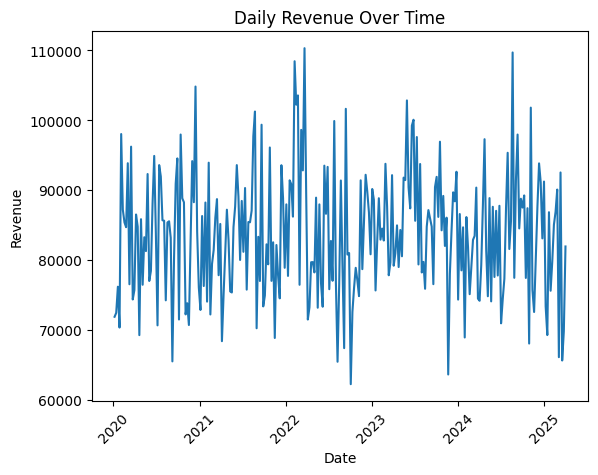

In [13]:
sns.lineplot(x="Date",y="Revenue",data=daily_sales)
plt.title("Daily Revenue Over Time")
plt.xticks(rotation=45)
plt.show()

In [14]:
category_revenue = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

In [15]:
category_revenue

,Revenue
Category,
Vitamin,4300224.68
Mineral,4276107.99
Performance,2909702.18
Protein,2855492.09
Amino Acid,1464819.63
Omega,1451065.87
Fat Burner,1440900.05
Hydration,1411951.38
Herbal,1405700.79


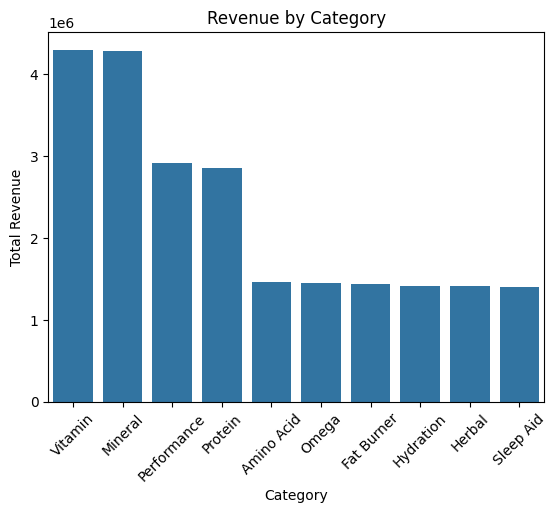

In [16]:
sns.barplot(x=category_revenue.index,y=category_revenue.values)
plt.title("Revenue by Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [17]:
loc_platform = df.groupby(["Location","Platform"])["Revenue"].sum().unstack().fillna(0)

In [18]:
loc_platform

Platform,Amazon,Walmart,iHerb
Location,,,
Canada,2613844.28,2518639.07,2716096.38
UK,2442671.23,2637066.25,2624222.86
USA,2612936.27,2232862.30,2514941.81


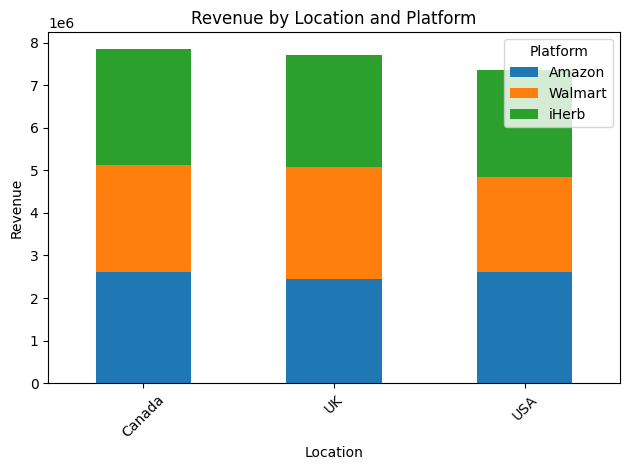

In [19]:
loc_platform.plot(kind="bar",stacked=True)
plt.title("Revenue by Location and Platform")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
top_products=df.groupby("Product Name")["Revenue"].sum().sort_values(ascending=False).head(10)

In [25]:
top_products

,Revenue
Product Name,
Biotin,1486798.62
Zinc,1482546.95
Pre-Workout,1477183.78
BCAA,1464819.63
Fish Oil,1451065.87
Green Tea Extract,1440900.05
Collagen Peptides,1433297.24
Creatine,1432518.40
Iron Supplement,1431582.41


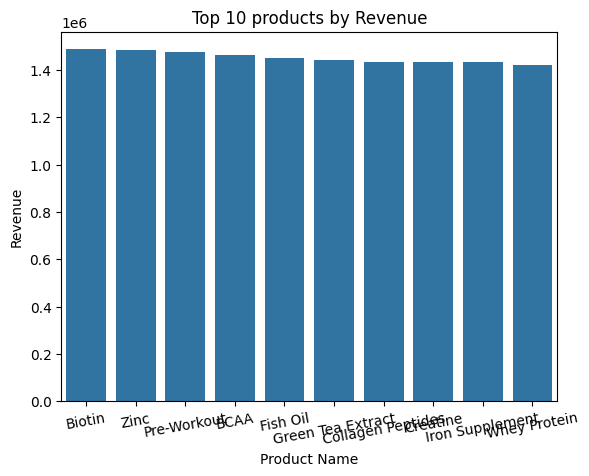

In [30]:
sns.barplot(x=top_products.index,y=top_products.values)
plt.title("Top 10 products by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=10)
plt.show()

In [31]:
df["Return Rate"] = df["Units Returned"]/df["Units Sold"]

In [34]:
df.head(10)

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Return Rate
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,0.013986
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon,0.000000
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,0.000000
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart,0.000000
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb,0.019108
5,2020-01-06,BCAA,Amino Acid,154,41.19,6343.26,0.13,1,UK,Walmart,0.006494
6,2020-01-06,Creatine,Performance,134,32.49,4353.66,0.05,1,UK,Walmart,0.007463
7,2020-01-06,Zinc,Mineral,147,46.68,6861.96,0.19,0,Canada,Amazon,0.000000
8,2020-01-06,Collagen Peptides,Protein,147,10.96,1611.12,0.06,2,USA,Amazon,0.013605
9,2020-01-06,Magnesium,Mineral,134,20.76,2781.84,0.00,0,Canada,Amazon,0.000000


In [35]:
category_return = df.groupby("Category")["Return Rate"].mean().sort_values(ascending=False)

In [36]:
category_return

,Return Rate
Category,
Hydration,0.010746
Vitamin,0.010475
Amino Acid,0.010355
Fat Burner,0.010229
Performance,0.010207
Protein,0.010203
Mineral,0.010079
Omega,0.009870
Sleep Aid,0.009860


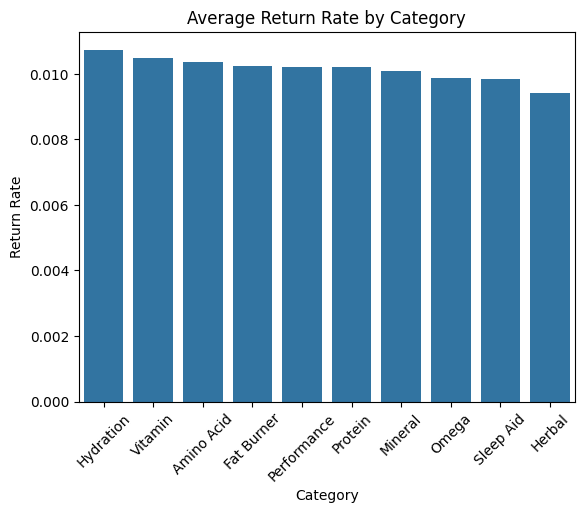

In [37]:
sns.barplot(x=category_return.index,y=category_return.values)
plt.title("Average Return Rate by Category")
plt.ylabel("Return Rate")
plt.xticks(rotation=45)
plt.show()

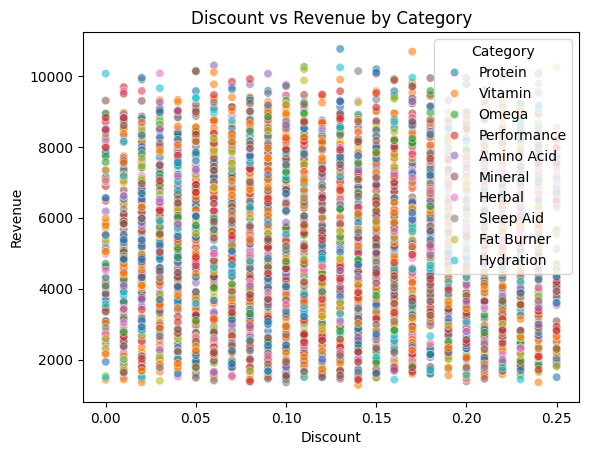

In [38]:
sns.scatterplot(data=df,x="Discount",y="Revenue",hue="Category",alpha=0.6)
plt.title("Discount vs Revenue by Category")
plt.show()

In [39]:
corr=df[["Units Sold","Price","Revenue","Discount","Units Returned"]].corr()

In [40]:
corr

,Units Sold,Price,Revenue,Discount,Units Returned
Units Sold,1.000000,0.013749,0.210462,-0.010435,0.116523
Price,0.013749,1.000000,0.977198,-0.008668,-0.010410
Revenue,0.210462,0.977198,1.000000,-0.012531,0.012432
Discount,-0.010435,-0.008668,-0.012531,1.000000,0.004276
Units Returned,0.116523,-0.010410,0.012432,0.004276,1.000000


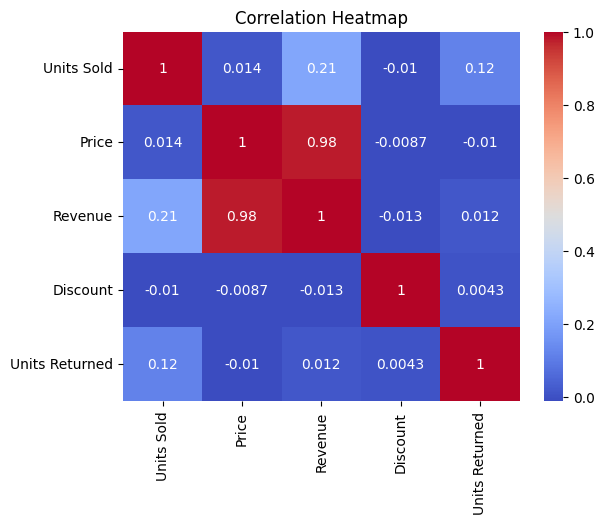

In [41]:
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [42]:
fig=px.line(df,x="Date",y="Revenue",color="Category",title="Revenue Over Time by Category")
fig.show()

In [43]:
df["Monthly"]=df["Date"].dt.to_period("M")
monthly=df.groupby("Monthly").agg({
    "Revenue":"sum",
    "Units Sold":"sum",
    "Discount":"mean",
    "Units Returned":"sum"
}).reset_index()

In [45]:
monthly["Monthly"]=monthly["Monthly"].astype(str)

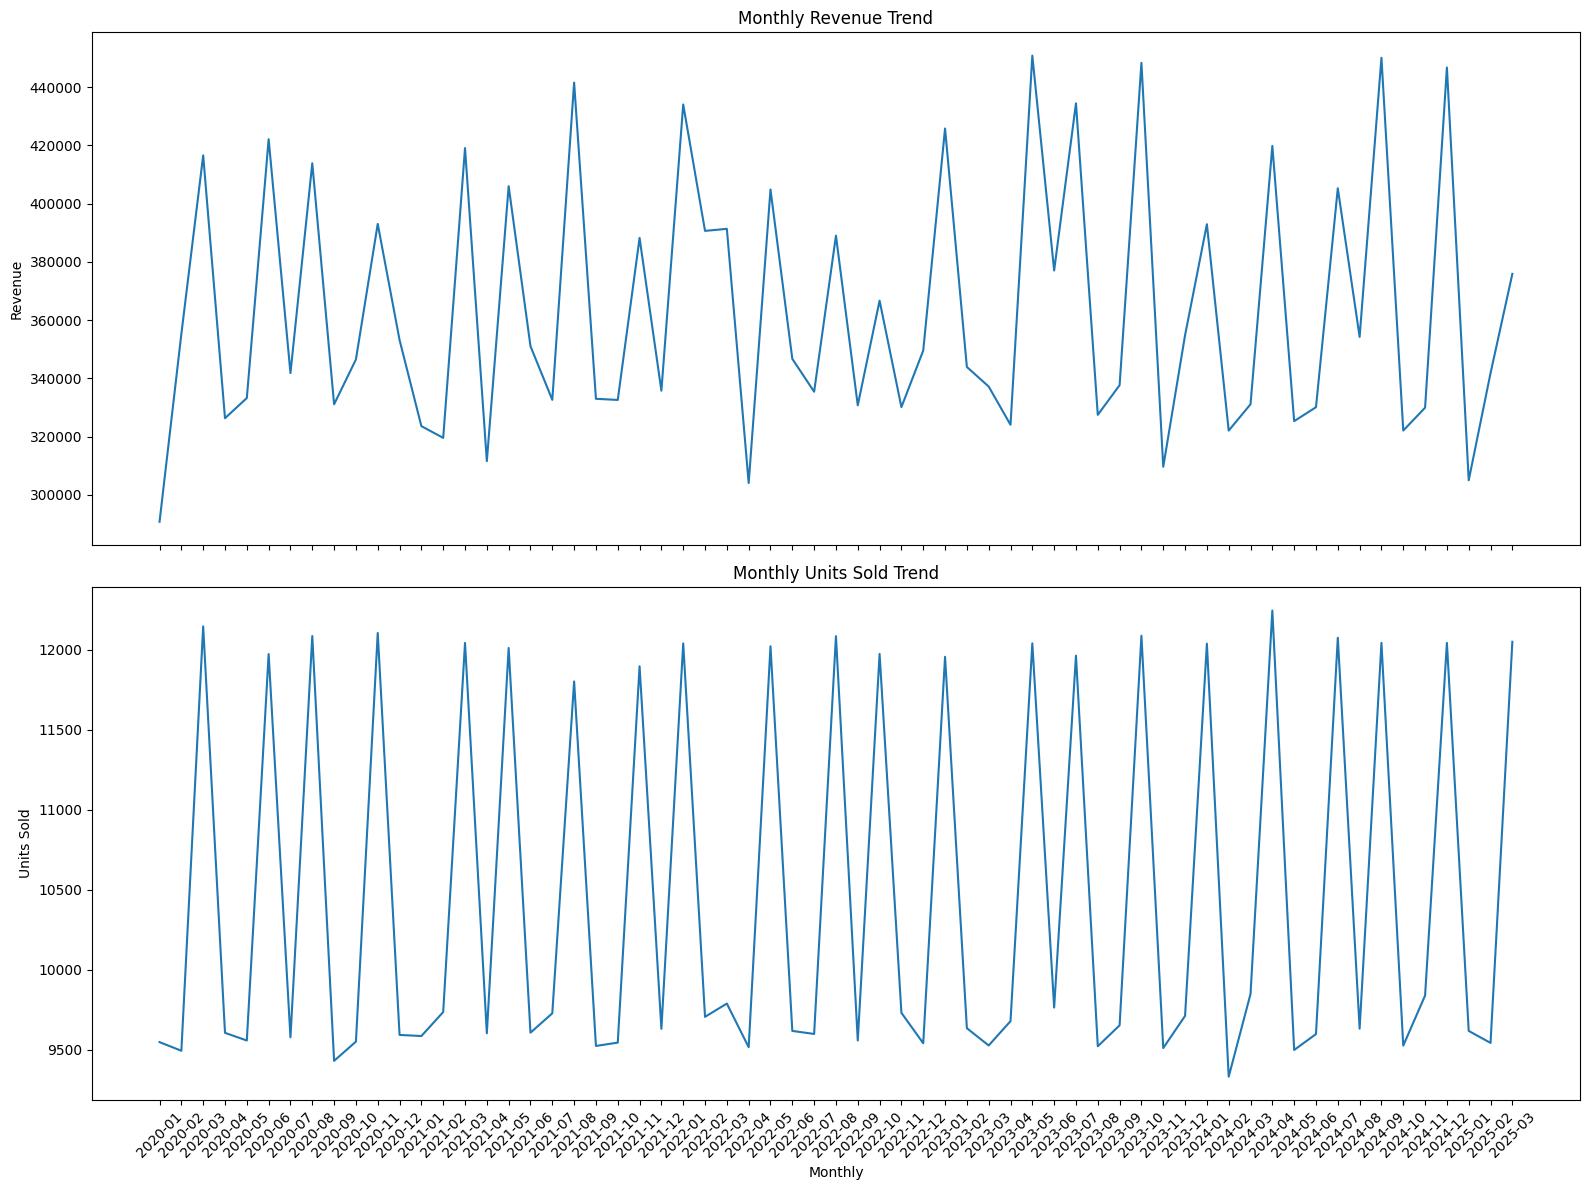

In [47]:
fig,axes=plt.subplots(2,1,sharex=True, figsize=(16,12))
sns.lineplot(data=monthly,x="Monthly",y="Revenue",ax=axes[0])
axes[0].set_title("Monthly Revenue Trend")
axes[0].tick_params(axis="x",rotation=45)

sns.lineplot(data=monthly,x="Monthly",y="Units Sold",ax=axes[1])
axes[1].set_title("Monthly Units Sold Trend")
axes[1].tick_params(axis="x",rotation=45)

plt.tight_layout()
plt.show()